# standard codes

In [153]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import time
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
from IPython.display import clear_output

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [154]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [155]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [156]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

#new codes

In [12]:
drive_path = '/content/drive/MyDrive/docs'
os.makedirs(drive_path, exist_ok=True)

In [157]:
files = np.sort(glob.glob(f"{drive_path}/sub*.json"))
logs = []
max_lines = 15

def log_message(message):
    logs.append(message)
    if len(logs) > max_lines:
        logs.pop(0) # Remove the oldest message
    clear_output(wait=True)
    for msg in logs:
        print(msg)

for i in range(snapshot['num_groups_subfind']):
    if i % int(snapshot['num_groups_subfind']/1000) == 0:
        log_message(str(i))

    if f"{drive_path}/sub{i}.json" in files:
        log_message(f"skipping i: {i}") # Log skipping
        continue # Skip the download part if file exists

    sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/{i}/"
    subhalo = get((sub_url), out_filename=f"{drive_path}/sub{i}.json")

    if i > 6:
        break

skipping i: 2661
skipping i: 2662
skipping i: 2663
skipping i: 2664
skipping i: 2665
skipping i: 2666
skipping i: 2667
skipping i: 2668
skipping i: 2669
skipping i: 2670
skipping i: 2671
skipping i: 2672
skipping i: 2673
skipping i: 2674
skipping i: 2675


KeyboardInterrupt: 

In [63]:
bhmdot = np.zeros(len(files)) -1
sfr = np.zeros(len(files)) -1

print('bhmdot: ', bhmdot)
print("sfr: ", sfr)

save_file = f"{drive_path}/bh_sfr.npz"
if os.path.exists(save_file):
    data = np.load(save_file)
    bhmdot[:len(data['bhmdot'])] = data['bhmdot']
    sfr[:len(data['sfr'])] = data['sfr']

print('bhmdot: ', bhmdot)
print("sfr: ", sfr)

for i in range(len(files)):
    if bhmdot[i] != -1:
        continue
    if sfr[i] != -1:
        continue
    with open(files[i], 'r') as fid:
        data = json.load(fid)
    bhmdot[i] = data['bhmdot']
    sfr[i] = data['sfr']
    if i > 1000:
        break
    np.savez_compressed(save_file, bhmdot=bhmdot, sfr=sfr)

bhmdot:  [-1. -1. -1. ... -1. -1. -1.]
sfr:  [-1. -1. -1. ... -1. -1. -1.]
bhmdot:  [ 3.51652e-03  1.66792e-02  5.11530e-04 ... -1.00000e+00 -1.00000e+00
 -1.00000e+00]
sfr:  [410.991    61.4731    1.57871 ...  -1.       -1.       -1.     ]


In [141]:
bhl = bhmdot[bhmdot != -1].tolist()
sfrl = sfr[sfr != -1].tolist()

bins = np.logspace(-4, 3, 50)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

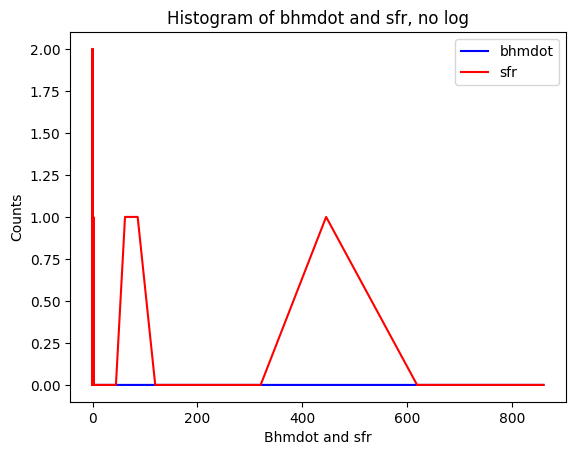

In [146]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr, no log')
#plt.yscale('log')
#plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()

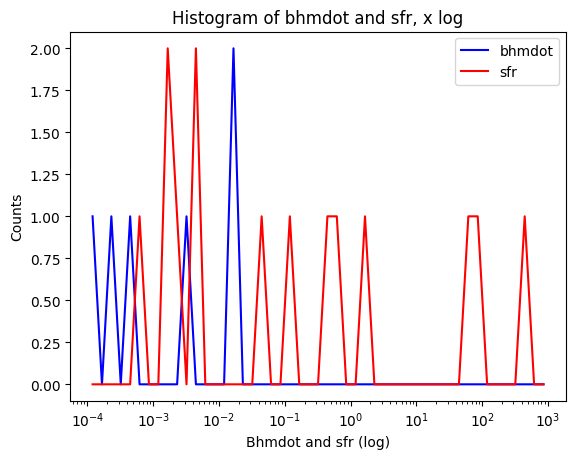

In [152]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr, x log')
#plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr (log)')
plt.legend()
plt.show()

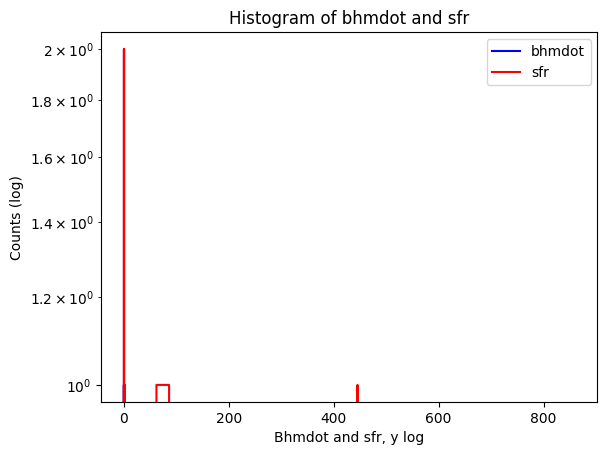

In [151]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr')
plt.yscale('log')
#plt.xscale('log')
plt.ylabel('Counts (log)')
plt.xlabel('Bhmdot and sfr, y log')
plt.legend()
plt.show()

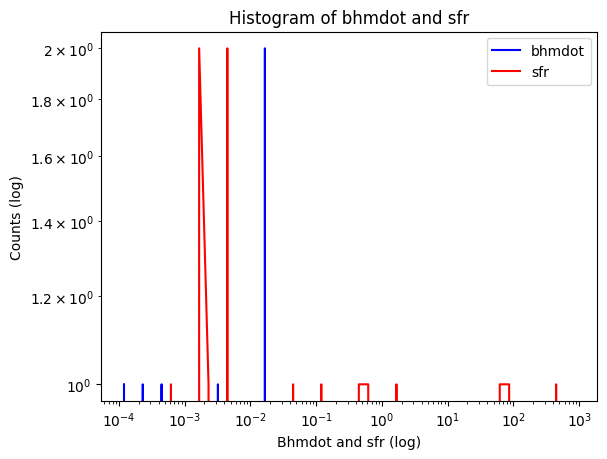

In [150]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts (log)')
plt.xlabel('Bhmdot and sfr (log)')
plt.legend()
plt.show()